# TIỂU LUẬN HỌC PHẦN IE201: XỬ LÝ DỮ LIỆU THỐNG KÊ

## Đề tài: Mối liên hệ giữa Cấu trúc Gia đình và Tỷ lệ Tội phạm Bạo lực tại Hoa Kỳ

---

### 1. Giới thiệu vấn đề nghiên cứu

**Bối cảnh:** Tội phạm bạo lực là vấn đề kinh tế-xã hội nghiêm trọng ảnh hưởng đến chất lượng sống của
cộng đồng. Nhiều nghiên cứu xã hội học đã chỉ ra rằng cấu trúc
gia đình thiếu hụt có liên hệ với tỷ lệ tội phạm cao hơn tại
các cộng đồng Hoa Kỳ. Bài toán này đã được cộng đồng khoa học nghiên cứu (ví dụ Redmond & Baveja, 2002,
công bố tập dữ liệu UCI Communities and Crime Unnormalized), nhưng phần lớn tập trung vào mô hình dự đoán (machine
learning) hơn là kiểm định thống kê suy luận cổ điển làm rõ ý nghĩa của cấu trúc gia đình.

**Mục tiêu nghiên cứu:** Sử dụng các phương pháp thống kê suy luận (ANOVA một yếu tố, kiểm định
Chi-bình phương) để trả lời câu hỏi nghiên cứu:

> **Cấu trúc gia đình có mối liên hệ có ý nghĩa thống kê với
> tỷ lệ tội phạm bạo lực của cộng đồng hay không?**

**Đối tượng và phạm vi dữ liệu:** Các cộng đồng (communities) tại Hoa Kỳ, dữ liệu điều tra dân số 1990,
dữ liệu tội phạm FBI UCR 1995, và dữ liệu thực thi pháp luật LEMAS 1990.

**Nguồn dữ liệu:** UCI Machine Learning Repository – *Communities and Crime Unnormalized* (ID = 211).
Link tham khảo: https://archive.ics.uci.edu/dataset/211

**Biến phân tích chính:**
- Biến độc lập (định lượng → được phân nhóm): `pctKids2Par` – Tỷ lệ trẻ em sống với cả cha và mẹ (%)
- Biến độc lập (định lượng → được phân nhóm): `pctKidsBornNevrMarr` – Tỷ lệ trẻ em sống trong gia đình đơn thân (%)
- Biến phụ thuộc (định lượng): `violentPerPop` – Số vụ tội phạm bạo lực / 100.000 dân

**Phương pháp thống kê áp dụng:**
1. Thống kê mô tả (đặc trưng số, biểu đồ phân phối)
2. Phân tích cỡ mẫu / kiểm tra điều kiện CLT
3. Phân tích Phương sai Một yếu tố (One-Way ANOVA) – so sánh trung bình tội phạm giữa 3 nhóm cấu trúc gia đình
4. Kiểm định Chi-bình phương – kiểm tra mối liên hệ giữa cấu trúc gia đình (định tính hoá) và mức độ tội phạm (định tính hoá)


## 1. Import thư viện và tải dữ liệu

**Mục đích:** Import các thư viện cần thiết cho xử lý dữ liệu (`pandas`, `numpy`), trực quan hóa
(`matplotlib`, `seaborn`) và kiểm định thống kê (`scipy.stats`), đồng thời tải bộ dữ liệu
*Communities and Crime Unnormalized* (ID=211) từ UCI ML Repository.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, levene, f as f_dist, t as t_dist
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Thư viện đã được import thành công!')

Thư viện đã được import thành công!


In [5]:
# Tải bộ dữ liệu Communities and Crime Unnormalized (ID = 211)
communities_and_crime_unnormalized = fetch_ucirepo(id=211)
df_raw = communities_and_crime_unnormalized.data.original

print(f'Kích thước dữ liệu gốc: {df_raw.shape[0]} dòng × {df_raw.shape[1]} cột')
df_raw.head()

Kích thước dữ liệu gốc: 2215 dòng × 147 cột


,communityname,State,countyCode,communityCode,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39.0,5320.0,1,11980,3.10,1.37,91.78,6.50,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,45.0,47616.0,1,23123,2.82,0.80,95.57,3.44,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,NaN,NaN,1,29344,2.43,0.74,94.33,3.43,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,35.0,29443.0,1,16656,2.40,1.70,97.35,0.50,...,225.0,1301.78,716.0,4142.56,47.0,271.93,NaN,NaN,306.64,NaN
4,Bemidjicity,MN,7.0,5068.0,1,11245,2.76,0.53,89.16,1.17,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,NaN,9988.79


**Nhận xét:** Dữ liệu gốc gồm 2.215 cộng đồng (dòng) và 147 thuộc tính (cột), bao gồm các biến
kinh tế-xã hội, nhân khẩu học, cấu trúc gia đình, và thống kê tội phạm. Dữ liệu cần được làm sạch
trước khi đưa vào phân tích vì chứa nhiều giá trị khuyết.

## 2. Tiền xử lý dữ liệu (Data Preprocessing)

**Mục đích:** Làm sạch dữ liệu phục vụ riêng cho câu hỏi nghiên cứu về cấu trúc gia đình: loại bỏ
các cột thiếu quá nhiều dữ liệu, loại các hàng thiếu biến mục tiêu `violentPerPop`, và điền giá trị
khuyết bằng trung vị cho các biến số còn lại (bao gồm `pctKids2Par` và `pctKidsBornNevrMarr`).

In [6]:
df_clean = df_raw.copy()

print('=== THÔNG TIN DỮ LIỆU TRƯỚC XỬ LÝ ===')
print(f'Số dòng ban đầu: {df_clean.shape[0]}')
print(f'Số biến: {df_clean.shape[1]}')

# --- 1. Loại bỏ các cột có tỷ lệ khuyết > 50% ---
missing_percent = df_clean.isnull().mean() * 100
cols_missing_over_50 = missing_percent[missing_percent > 50].index
df_clean = df_clean.drop(columns=cols_missing_over_50)
print(f'Đã loại bỏ {len(cols_missing_over_50)} cột do thiếu > 50% dữ liệu.')

# --- 2. Xóa hàng thiếu biến mục tiêu ---
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=['violentPerPop'])
print(f'Đã xóa {rows_before - len(df_clean)} hàng do thiếu giá trị biến mục tiêu.')

# --- 3. Điền Median cho các biến số còn lại ---
feature_cols = df_clean.select_dtypes(include=[np.number]).columns.drop('violentPerPop')
df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].median())

print('\n=== THÔNG TIN DỮ LIỆU SAU XỬ LÝ ===')
print(f'Số dòng để phân tích: {df_clean.shape[0]}')
print(f'Kiểm tra lại missing values: {df_clean.isnull().sum().sum()}')

# --- Đã sửa: Bổ sung thêm biến pctKidsBornNevrMarr ---
print(f"\nCác biến cấu trúc gia đình ('pctKids2Par' và 'pctKidsBornNevrMarr') - giá trị mẫu:")
print(df_clean[['pctKids2Par', 'pctKidsBornNevrMarr']].describe().round(2))

=== THÔNG TIN DỮ LIỆU TRƯỚC XỬ LÝ ===
Số dòng ban đầu: 2215
Số biến: 147
Đã loại bỏ 24 cột do thiếu > 50% dữ liệu.
Đã xóa 221 hàng do thiếu giá trị biến mục tiêu.

=== THÔNG TIN DỮ LIỆU SAU XỬ LÝ ===
Số dòng để phân tích: 1994
Kiểm tra lại missing values: 0

Các biến cấu trúc gia đình ('pctKids2Par' và 'pctKidsBornNevrMarr') - giá trị mẫu:
       pctKids2Par  pctKidsBornNevrMarr
count      1994.00              1994.00
mean         70.91                 3.14
std          11.85                 3.07
min          26.11                 0.00
25%          63.62                 1.08
50%          72.06                 2.08
75%          79.82                 3.98
max          92.58                24.19


**Nhận xét:** Sau tiền xử lý, dữ liệu còn lại đầy đủ (không còn giá trị khuyết) với cỡ mẫu lớn,
đủ điều kiện áp dụng các phương pháp suy luận thống kê. Hai biến `pctKids2Par` và `pctKidsBornNevrMarr` (tỷ lệ trẻ em sống với
đủ cha mẹ) dao động từ giá trị thấp đến gần 100%, phù hợp để phân nhóm thành 3 mức trong phân tích ANOVA.

## 3. Thống kê Mô tả (Descriptive Statistics)

**Mục đích:** Tính các đặc trưng số (trung bình, trung vị, độ lệch chuẩn, skewness, kurtosis) của
hai biến trọng tâm cho câu hỏi nghiên cứu: `violentPerPop` (tỷ lệ tội phạm bạo lực) và `pctKids2Par`
(tỷ lệ trẻ em sống với đủ cha mẹ – đại diện cho cấu trúc gia đình).

In [7]:
key_vars = ['violentPerPop', 'pctKids2Par', 'pctKidsBornNevrMarr']
key_vars = [v for v in key_vars if v in df_clean.columns]

desc = df_clean[key_vars].describe().round(2)
print('=== THỐNG KÊ MÔ TẢ: TỘI PHẠM BẠO LỰC & CẤU TRÚC GIA ĐÌNH ===')
print(desc)

print('\nĐộ lệch (Skewness):')
print(df_clean[key_vars].skew().round(3))
print('\nĐộ nhọn (Kurtosis):')
print(df_clean[key_vars].kurtosis().round(3))

# --- Hệ số tương quan cho từng biến ---
print(f"\nHệ số tương quan Pearson (violentPerPop, pctKids2Par) = "
      f"{df_clean['violentPerPop'].corr(df_clean['pctKids2Par']):.4f}")
print(f"Hệ số tương quan Pearson (violentPerPop, pctKidsBornNevrMarr) = "
      f"{df_clean['violentPerPop'].corr(df_clean['pctKidsBornNevrMarr']):.4f}")

# --- Ma trận tương quan (Correlation Matrix) ---
print("\n=== MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ===")
print(df_clean[key_vars].corr().round(4))

=== THỐNG KÊ MÔ TẢ: TỘI PHẠM BẠO LỰC & CẤU TRÚC GIA ĐÌNH ===
       violentPerPop  pctKids2Par  pctKidsBornNevrMarr
count        1994.00      1994.00              1994.00
mean          589.08        70.91                 3.14
std           614.78        11.85                 3.07
min             0.00        26.11                 0.00
25%           161.70        63.62                 1.08
50%           374.06        72.06                 2.08
75%           794.40        79.82                 3.98
max          4877.06        92.58                24.19

Độ lệch (Skewness):
violentPerPop          2.067
pctKids2Par           -0.642
pctKidsBornNevrMarr    2.091
dtype: float64

Độ nhọn (Kurtosis):
violentPerPop          5.597
pctKids2Par            0.245
pctKidsBornNevrMarr    5.680
dtype: float64

Hệ số tương quan Pearson (violentPerPop, pctKids2Par) = -0.7281
Hệ số tương quan Pearson (violentPerPop, pctKidsBornNevrMarr) = 0.7381

=== MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ===
             

**Nhận xét:**
- `violentPerPop` có skewness dương lớn (lệch phải mạnh). Đa số cộng đồng có tỷ lệ tội
phạm thấp nhưng tồn tại một số cộng đồng có tỷ lệ rất cao. `pctKids2Par` có skewness âm nhẹ, cho thấy
đa số cộng đồng có tỷ lệ gia đình đủ cha mẹ khá cao. Ngược lại, `pctKidsBornNevrMarr` có skewness dương cho thấy đa số các cộng đồng có tỷ lệ sinh ngoài giá thú thấp nhưng vẫn có những khu vực tỷ lệ này vọt lên rất cao
- Hai biến gia đình thể hiện tác động hoàn toàn trái chiều: pctKids2Par có tương quan âm đáng kể (tỷ lệ gia đình đủ cha mẹ càng cao thì tỷ lệ tội phạm bạo lực càng thấp), trong khi pctKidsBornNevrMarr có tương quan dương rất mạnh (tỷ lệ trẻ sinh ra từ cha mẹ chưa kết hôn càng cao thì tội phạm càng gia tăng).

**Mục đích:** Trực quan hóa phân phối của ba biến chính bằng histogram, làm cơ sở đánh giá hình dạng
phân phối trước khi áp dụng các kiểm định suy luận.

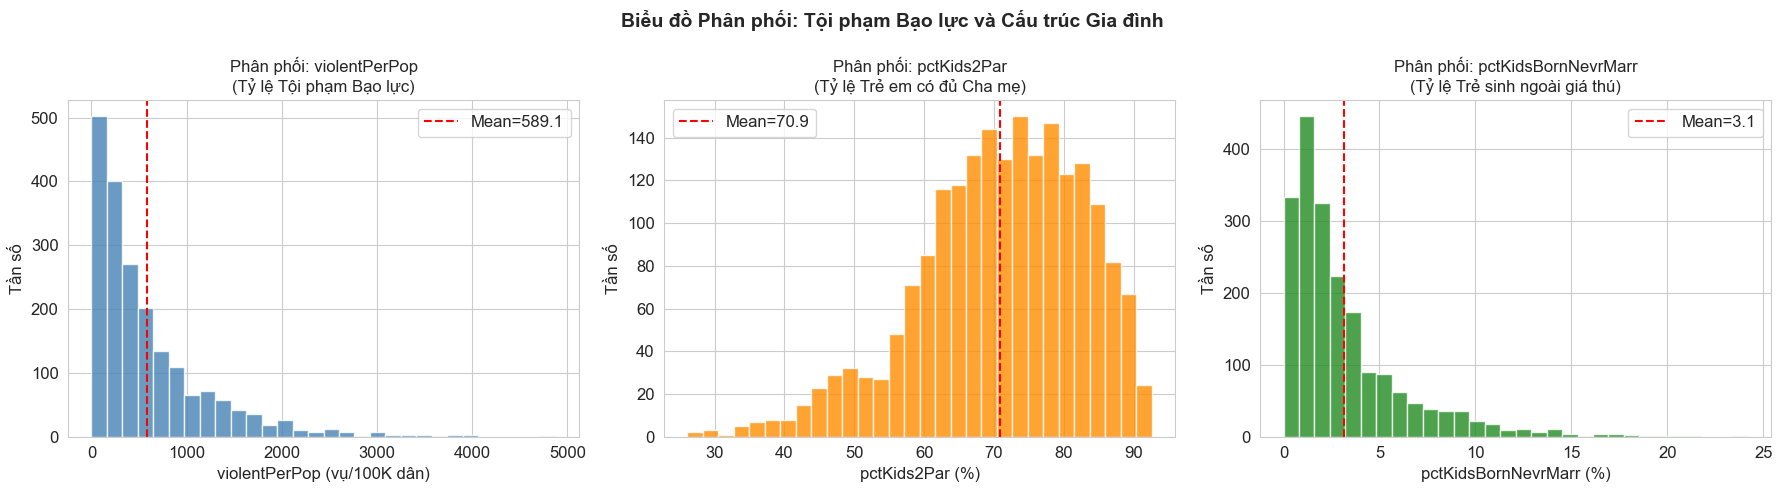

Biểu đồ phân phối của ba biến nghiên cứu chính


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Biểu đồ cho violentPerPop
axes[0].hist(df_clean['violentPerPop'].dropna(), bins=30, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].axvline(df_clean['violentPerPop'].mean(), color='red', linestyle='--',
                label=f"Mean={df_clean['violentPerPop'].mean():.1f}")
axes[0].set_title('Phân phối: violentPerPop\n(Tỷ lệ Tội phạm Bạo lực)', fontsize=12)
axes[0].set_xlabel('violentPerPop (vụ/100K dân)')
axes[0].set_ylabel('Tần số')
axes[0].legend()

# 2. Biểu đồ cho pctKids2Par
axes[1].hist(df_clean['pctKids2Par'].dropna(), bins=30, color='darkorange',
             edgecolor='white', alpha=0.8)
axes[1].axvline(df_clean['pctKids2Par'].mean(), color='red', linestyle='--',
                label=f"Mean={df_clean['pctKids2Par'].mean():.1f}")
axes[1].set_title('Phân phối: pctKids2Par\n(Tỷ lệ Trẻ em có đủ Cha mẹ)', fontsize=12)
axes[1].set_xlabel('pctKids2Par (%)')
axes[1].set_ylabel('Tần số')
axes[1].legend()

# 3. Biểu đồ cho pctKidsBornNevrMarr
axes[2].hist(df_clean['pctKidsBornNevrMarr'].dropna(), bins=30, color='forestgreen',
             edgecolor='white', alpha=0.8)
axes[2].axvline(df_clean['pctKidsBornNevrMarr'].mean(), color='red', linestyle='--',
                label=f"Mean={df_clean['pctKidsBornNevrMarr'].mean():.1f}")
axes[2].set_title('Phân phối: pctKidsBornNevrMarr\n(Tỷ lệ Trẻ sinh ngoài giá thú)', fontsize=12)
axes[2].set_xlabel('pctKidsBornNevrMarr (%)')
axes[2].set_ylabel('Tần số')
axes[2].legend()

plt.suptitle('Biểu đồ Phân phối: Tội phạm Bạo lực và Cấu trúc Gia đình',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phan_phoi.png', dpi=300, bbox_inches='tight')
plt.show()
print('Biểu đồ phân phối của ba biến nghiên cứu chính')

**Nhận xét:**
- `violentPerPop`: Phân phối lệch phải rất mạnh, đa số cộng đồng tập trung ở mức tội phạm thấp (gần 0), một số ít có tỷ lệ tội phạm cực cao – đặc trưng của dữ liệu đếm/tỷ lệ trong thực tế.
- `pctKids2Par`: Phân phối lệch trái nhẹ, đa số cộng đồng có tỷ lệ trẻ em đủ cha mẹ ở mức khá cao (60–90%), số cộng đồng có tỷ lệ rất thấp (cấu trúc gia đình yếu) chiếm thiểu số nhưng đáng chú ý.
- `pctKidsBornNevrMarr`: Phân phối lệch phải khá rõ nét. Phần lớn các cộng đồng có tỷ lệ trẻ sinh ra từ cha mẹ chưa từng kết hôn ở mức thấp, tuy nhiên vẫn có một "cái đuôi" dài (long tail) kéo về bên phải, cho thấy có những khu vực tỷ lệ này vọt lên rất cao, phản ánh sự rạn nứt/yếu kém cục bộ trong cấu trúc gia đình tại các khu vực đó.

**Mục đích:** So sánh trực quan tỷ lệ tội phạm bạo lực giữa các nhóm cộng đồng có mức độ cấu trúc
gia đình khác nhau (Thấp / Trung bình / Cao), thông qua boxplot (phân tán) và bar chart (trung bình).

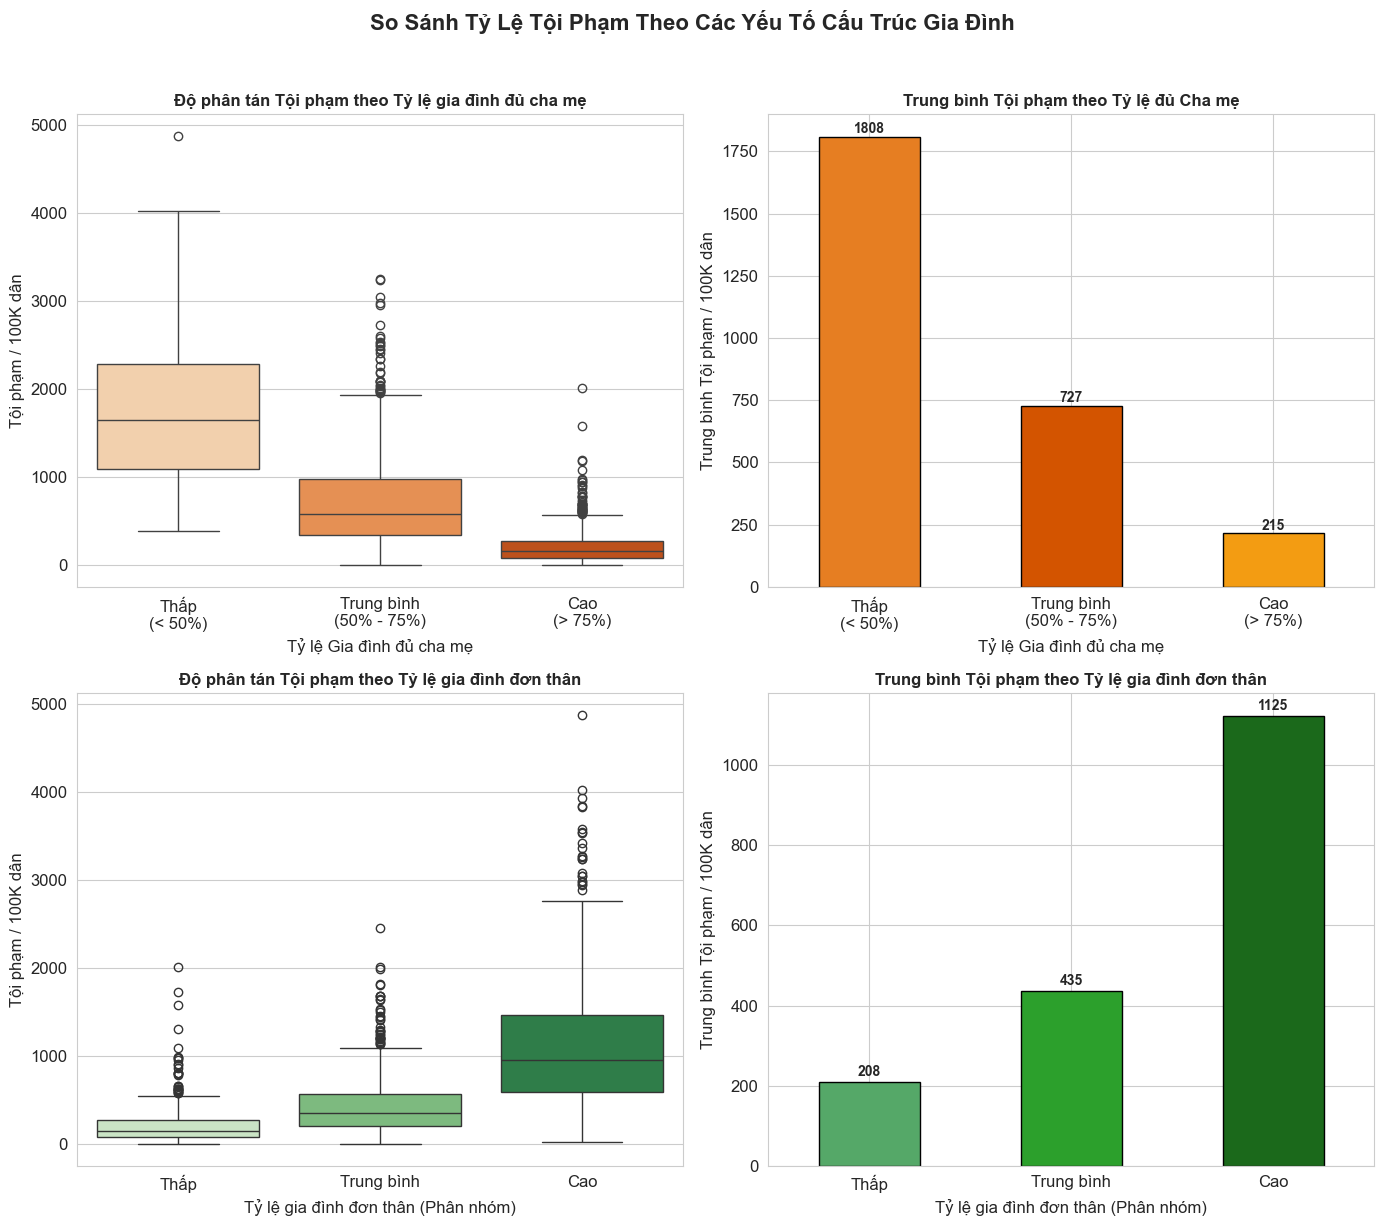

Biểu đồ: So sánh Tỷ lệ tội phạm bạo lực theo tỷ lệ gia đình đủ cha mẹ và gia đình đơn thân


In [9]:
# 1. Tạo biến phân nhóm cho Cấu trúc gia đình (pctKids2Par)
df_clean['family_group_2par'] = pd.cut(
    df_clean['pctKids2Par'],
    bins=[0, 50, 75, 100],
    labels=['Thấp\n(< 50%)', 'Trung bình\n(50% - 75%)', 'Cao\n(> 75%)']
)

# 2. Tạo biến phân nhóm cho pctKidsBornNevrMarr
# Sử dụng qcut để chia đều thành 3 nhóm dựa trên phân vị của dữ liệu
df_clean['family_group_nevrMarr'] = pd.qcut(
    df_clean['pctKidsBornNevrMarr'],
    q=3,
    labels=['Thấp', 'Trung bình', 'Cao']
)

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ================= Biến pctKids2Par =================
sns.boxplot(data=df_clean, x='family_group_2par', y='violentPerPop', ax=axes[0, 0], palette='Oranges')
axes[0, 0].set_title('Độ phân tán Tội phạm theo Tỷ lệ gia đình đủ cha mẹ', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tỷ lệ Gia đình đủ cha mẹ')
axes[0, 0].set_ylabel('Tội phạm / 100K dân')

family_means_2par = df_clean.groupby('family_group_2par')['violentPerPop'].mean()
family_means_2par.plot(kind='bar', ax=axes[0, 1], color=['#e67e22', '#d35400', '#f39c12'], edgecolor='black')
axes[0, 1].set_title('Trung bình Tội phạm theo Tỷ lệ đủ Cha mẹ', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tỷ lệ Gia đình đủ cha mẹ')
axes[0, 1].set_ylabel('Trung bình Tội phạm / 100K dân')
axes[0, 1].tick_params(axis='x', rotation=0)

for bar, val in zip(axes[0, 1].patches, family_means_2par):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
                    f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

# ================= Biến pctKidsBornNevrMarr =================
sns.boxplot(data=df_clean, x='family_group_nevrMarr', y='violentPerPop', ax=axes[1, 0], palette='Greens')
axes[1, 0].set_title('Độ phân tán Tội phạm theo Tỷ lệ gia đình đơn thân', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tỷ lệ gia đình đơn thân (Phân nhóm)')
axes[1, 0].set_ylabel('Tội phạm / 100K dân')

family_means_nevr = df_clean.groupby('family_group_nevrMarr')['violentPerPop'].mean()
family_means_nevr.plot(kind='bar', ax=axes[1, 1], color=['#55a868', '#2ca02c', '#1b691b'], edgecolor='black')
axes[1, 1].set_title('Trung bình Tội phạm theo Tỷ lệ gia đình đơn thân', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tỷ lệ gia đình đơn thân (Phân nhóm)')
axes[1, 1].set_ylabel('Trung bình Tội phạm / 100K dân')
axes[1, 1].tick_params(axis='x', rotation=0)

for bar, val in zip(axes[1, 1].patches, family_means_nevr):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
                    f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

# Cài đặt tiêu đề
plt.suptitle('So Sánh Tỷ Lệ Tội Phạm Theo Các Yếu Tố Cấu Trúc Gia Đình', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('so_sanh.png', dpi=300, bbox_inches='tight')
plt.show()

print('Biểu đồ: So sánh Tỷ lệ tội phạm bạo lực theo tỷ lệ gia đình đủ cha mẹ và gia đình đơn thân')

**Nhận xét:** Cấu trúc gia đình có tác động trực quan rất rõ rệt và đa chiều đến tỷ lệ tội phạm.
- **Với tỷ lệ trẻ em có đủ cha mẹ (`pctKids2Par`):** Ở những cộng đồng có dưới 50% trẻ em sống với đủ cha mẹ, tỷ lệ tội phạm bạo lực tăng vọt và độ phân tán dữ liệu rất lớn (chứa nhiều điểm ngoại lai). Ngược lại, khi nền tảng gia đình vững chắc (trên 75% trẻ em sống cùng cả cha lẫn mẹ), tỷ lệ tội phạm bạo lực giảm mạnh và gần như bị triệt tiêu.
- **Với tỷ lệ trẻ em trong gia đình đơn thân (`pctKidsBornNevrMarr`):** Xu hướng hoàn toàn ngược lại nhưng mang ý nghĩa tương đồng về mặt rủi ro. Ở các cộng đồng thuộc nhóm có tỷ lệ trẻ em trong gia đình đơn thân "Cao", trung bình số vụ tội phạm bạo lực vượt trội hơn hẳn so với hai nhóm còn lại, đồng thời biên độ dao động của tội phạm cũng rất rộng.

Sự khác biệt rõ rệt ở cả hai khía cạnh này củng cố mạnh mẽ cho giả thuyết nghiên cứu và cần được kiểm định chính thức bằng phương pháp ANOVA để xác nhận mức độ ý nghĩa thống kê.

## 4. Phân tích Cỡ mẫu (Sample Size Analysis)

**Mục đích:** Trước khi thực hiện các kiểm định giả thuyết (ANOVA, Chi-bình phương), cần kiểm tra
cỡ mẫu hiện tại có đủ lớn để Định lý Giới hạn Trung tâm (CLT) có hiệu lực hay không, ước lượng sai
số chuẩn (SE) của trung bình mẫu, và xác định cỡ mẫu tối thiểu cần thiết cho độ chính xác mong muốn.

In [10]:
import math
from scipy.stats import norm

target = 'violentPerPop'
y = df_clean[target].dropna()

print('=== KIỂM TRA ĐIỀU KIỆN CLT ===')
n_current = len(y)
print(f'Cỡ mẫu hiện tại n = {n_current}')
print(f'n >= 30? {"Có" if n_current >= 30 else "Không"}')

mu_hat    = y.mean()
sigma_hat = y.std(ddof=1)
se        = sigma_hat / math.sqrt(n_current)

print('\n=== PHÂN PHỐI CỦA TRUNG BÌNH MẪU (Sampling Distribution of ȳ) ===')
print(f'  Trung bình mẫu  ȳ     = {mu_hat:.2f}')
print(f'  Độ lệch chuẩn mẫu s   = {sigma_hat:.2f}')
print(f'  Sai số chuẩn SE = s/√n = {se:.4f}')

z_95 = norm.ppf(0.975)
ci95 = (mu_hat - z_95*se, mu_hat + z_95*se)
print(f'\n  95% CI cho μ: ({ci95[0]:.2f}, {ci95[1]:.2f})')

# Cỡ mẫu cần thiết cho sai số E mong muốn
sigma_est = (y.max() - y.min()) / 4
E_target = 55
n_needed = math.ceil((1.96 * sigma_est / E_target) ** 2)
print(f'\n=== CỠ MẪU CẦN THIẾT ===')
print(f'  Với sai số cho phép E = {E_target}, α = 0.05: cần n ≥ {n_needed}')
print(f'  Cỡ mẫu hiện tại n = {n_current} {">=" if n_current >= n_needed else "<"} {n_needed}')

=== KIỂM TRA ĐIỀU KIỆN CLT ===
Cỡ mẫu hiện tại n = 1994
n >= 30? Có

=== PHÂN PHỐI CỦA TRUNG BÌNH MẪU (Sampling Distribution of ȳ) ===
  Trung bình mẫu  ȳ     = 589.08
  Độ lệch chuẩn mẫu s   = 614.78
  Sai số chuẩn SE = s/√n = 13.7677

  95% CI cho μ: (562.09, 616.06)

=== CỠ MẪU CẦN THIẾT ===
  Với sai số cho phép E = 55, α = 0.05: cần n ≥ 1888
  Cỡ mẫu hiện tại n = 1994 >= 1888


**Nhận xét:** Cỡ mẫu hiện tại (n ≈ 1.994) lớn hơn rất nhiều so với ngưỡng tối thiểu cần thiết
(n ≥ 30 theo CLT, và cũng vượt xa cỡ mẫu cần để đạt sai số mong muốn). Mặc dù biến `violentPerPop`
có phân phối quần thể lệch phải mạnh (không chuẩn), nhưng với cỡ mẫu rất lớn này, theo Định lý Giới
hạn Trung tâm, phân phối của trung bình mẫu trong mỗi nhóm con (khi phân tích ANOVA) vẫn sẽ xấp xỉ
phân phối chuẩn. Do đó các kiểm định thống kê suy luận tiếp theo (ANOVA, Chi-bình phương) hoàn toàn
có cơ sở áp dụng và đảm bảo độ tin cậy.

## 5. Phân tích Phương sai Một yếu tố (One-Way ANOVA)

**Câu hỏi nghiên cứu:** Tỷ lệ tội phạm bạo lực có khác nhau có ý nghĩa thống kê giữa các cộng đồng có mức độ cấu trúc gia đình khác nhau hay không? (Xét trên 2 khía cạnh: Tỷ lệ gia đình đủ cha mẹ và Tỷ lệ gia đình đơn thân).

- $H_0$: $\mu_1 = \mu_2 = \mu_3$ (Trung bình tỷ lệ tội phạm giữa 3 nhóm cấu trúc gia đình bằng nhau)
- $H_a$: Tồn tại ít nhất hai nhóm có trung bình tỷ lệ tội phạm khác nhau

**Điều kiện áp dụng ANOVA:**
1. Các mẫu (3 nhóm) độc lập với nhau.
2. Phân phối của mỗi nhóm xấp xỉ chuẩn (hoặc cỡ mẫu đủ lớn để CLT đảm bảo).
3. Phương sai đồng nhất giữa các nhóm (Homogeneity of Variance) - Kiểm định Levene.

**Mục đích:** Chuẩn bị dữ liệu cho ANOVA bằng cách phân nhóm hai biến `pctKids2Par` và `pctKidsBornNevrMarr` thành 3 mức
(Thấp <50%, Trung bình 50-75%, Cao >75%) và trích xuất giá trị `violentPerPop` tương ứng mỗi nhóm,
đồng thời kiểm tra điều kiện đẳng phương sai (Levene test).

In [11]:
# ── Chuẩn bị dữ liệu cho ANOVA ──
# 1. Biến Tỷ lệ đủ cha mẹ (pctKids2Par)
df_clean['family_cat'] = pd.cut(
    df_clean['pctKids2Par'],
    bins=[0, 50, 75, 100],
    labels=['Thấp (<50%)', 'Trung bình (50-75%)', 'Cao (>75%)']
)
group_labels = ['Thấp (<50%)', 'Trung bình (50-75%)', 'Cao (>75%)']
groups = [
    df_clean[df_clean['family_cat'] == lbl]['violentPerPop'].dropna().values
    for lbl in group_labels
]

# 2. Biến Tỷ lệ gia đình đơn thân (pctKidsBornNevrMarr)
df_clean['nevr_marr_cat'] = pd.qcut(
    df_clean['pctKidsBornNevrMarr'],
    q=3,
    labels=['Thấp', 'Trung bình', 'Cao']
)
group_labels_nevr = ['Thấp', 'Trung bình', 'Cao']
groups_nevr = [
    df_clean[df_clean['nevr_marr_cat'] == lbl]['violentPerPop'].dropna().values
    for lbl in group_labels_nevr
]

# ── Thống kê và Kiểm tra đẳng phương sai ──
print('=== 1. TỶ LỆ ĐỦ CHA MẸ (pctKids2Par) ===')
for lbl, g in zip(group_labels, groups):
    print(f'  {lbl:<22} n={len(g):>5}  mean={g.mean():>8.2f}  std={g.std():>8.2f}')
stat_lev, p_lev = levene(*groups)
print(f'  Levene Test: Statistic = {stat_lev:.4f}, p-value = {p_lev:.6f}')

print('\n=== 2. TỶ LỆ GIA ĐÌNH ĐƠN THÂN (pctKidsBornNevrMarr) ===')
for lbl, g in zip(group_labels_nevr, groups_nevr):
    print(f'  {lbl:<22} n={len(g):>5}  mean={g.mean():>8.2f}  std={g.std():>8.2f}')
stat_lev_nevr, p_lev_nevr = levene(*groups_nevr)
print(f'  Levene Test: Statistic = {stat_lev_nevr:.4f}, p-value = {p_lev_nevr:.6f}')
print(f'\n→ Phương sai giữa các nhóm không hoàn toàn bằng nhau (α=0.05);'
      f' tuy nhiên ANOVA vẫn khá bền vững (robust) với vi phạm nhẹ khi cỡ mẫu lớn.')

=== 1. TỶ LỆ ĐỦ CHA MẸ (pctKids2Par) ===
  Thấp (<50%)            n=  128  mean= 1808.27  std=  898.61
  Trung bình (50-75%)    n= 1059  mean=  727.03  std=  528.43
  Cao (>75%)             n=  807  mean=  214.67  std=  194.89
  Levene Test: Statistic = 251.7558, p-value = 0.000000

=== 2. TỶ LỆ GIA ĐÌNH ĐƠN THÂN (pctKidsBornNevrMarr) ===
  Thấp                   n=  665  mean=  208.02  std=  203.95
  Trung bình             n=  665  mean=  435.50  std=  341.70
  Cao                    n=  664  mean= 1124.52  std=  721.18
  Levene Test: Statistic = 252.8399, p-value = 0.000000

→ Phương sai giữa các nhóm không hoàn toàn bằng nhau (α=0.05); tuy nhiên ANOVA vẫn khá bền vững (robust) với vi phạm nhẹ khi cỡ mẫu lớn.


**Nhận xét:** Các nhóm của cả hai biến cấu trúc gia đình đều có cỡ mẫu lớn, cho phép áp dụng ANOVA tin cậy. Trung bình tỷ lệ tội phạm giảm dần rõ rệt từ nhóm "Thấp" sang nhóm "Cao" ở biến tỷ lệ đủ cha mẹ; và tăng vọt từ nhóm "Thấp" sang "Cao" ở biến tỷ lệ gia đình đơn thân. Kiểm định Levene cho thấy phương sai có sự khác biệt, nhưng cỡ mẫu đủ lớn giúp ANOVA vẫn đảm bảo độ tin cậy.

**Mục đích:** Tính bảng phân tích phương sai (ANOVA table) theo công thức thủ công (SSB, SSW, SST, MSB, MSW, F) để hiểu rõ bản chất kiểm định, đồng thời xác minh lại kết quả bằng hàm `scipy.stats.f_oneway` cho cả hai biến.

In [12]:
# ── Tính ANOVA thủ công và bằng scipy cho biến pctKids2Par ──
k = len(groups)
N = sum(len(g) for g in groups)
grand_mean_val = np.concatenate(groups).mean()

SSB = sum(len(g) * (g.mean() - grand_mean_val) ** 2 for g in groups)
SSW = sum(((g - g.mean()) ** 2).sum() for g in groups)
SST = SSB + SSW

df_between = k - 1
df_within = N - k
MSB = SSB / df_between
MSW = SSW / df_within
F_stat = MSB / MSW

alpha_anova = 0.05
F_critical = f_dist.ppf(1 - alpha_anova, df_between, df_within)
p_anova = f_dist.sf(F_stat, df_between, df_within)

print('=== ANOVA: TỶ LỆ ĐỦ CHA MẸ (pctKids2Par) ===')
print(f'  Giữa các nhóm (SSB) : {SSB:>12.2f} | df: {df_between} | MSB: {MSB:>10.4f} | F: {F_stat:.4f}')
print(f'  Trong nội bộ (SSW)  : {SSW:>12.2f} | df: {df_within} | MSW: {MSW:>10.4f}')
print(f'  F_crit = {F_critical:.4f}, p-value = {p_anova:.6e}')
F_scipy, p_scipy = f_oneway(*groups)
print(f'  Xác minh scipy: F = {F_scipy:.4f}, p = {p_scipy:.6e}\n')

# ── Tính ANOVA thủ công và bằng scipy cho biến pctKidsBornNevrMarr ──
k_nevr = len(groups_nevr)
N_nevr = sum(len(g) for g in groups_nevr)
grand_mean_val_nevr = np.concatenate(groups_nevr).mean()

SSB_nevr = sum(len(g) * (g.mean() - grand_mean_val_nevr) ** 2 for g in groups_nevr)
SSW_nevr = sum(((g - g.mean()) ** 2).sum() for g in groups_nevr)

df_between_nevr = k_nevr - 1
df_within_nevr = N_nevr - k_nevr
MSB_nevr = SSB_nevr / df_between_nevr
MSW_nevr = SSW_nevr / df_within_nevr
F_stat_nevr = MSB_nevr / MSW_nevr

F_critical_nevr = f_dist.ppf(1 - alpha_anova, df_between_nevr, df_within_nevr)
p_anova_nevr = f_dist.sf(F_stat_nevr, df_between_nevr, df_within_nevr)

print('=== ANOVA: TỶ LỆ GIA ĐÌNH ĐƠN THÂN (pctKidsBornNevrMarr) ===')
print(
    f'  Giữa các nhóm (SSB) : {SSB_nevr:>12.2f} | df: {df_between_nevr} | MSB: {MSB_nevr:>10.4f} | F: {F_stat_nevr:.4f}')
print(f'  Trong nội bộ (SSW)  : {SSW_nevr:>12.2f} | df: {df_within_nevr} | MSW: {MSW_nevr:>10.4f}')
print(f'  F_crit = {F_critical_nevr:.4f}, p-value = {p_anova_nevr:.6e}')
F_scipy_nevr, p_scipy_nevr = f_oneway(*groups_nevr)
print(f'  Xác minh scipy: F = {F_scipy_nevr:.4f}, p = {p_scipy_nevr:.6e}\n')

print(f'KẾT LUẬN: Cả hai biến đều có F > F_crit và p-value < 0.05')
print(f'  → Bác bỏ H₀: Có sự khác biệt có ý nghĩa thống kê về tỷ lệ tội phạm giữa các mức độ cấu trúc gia đình.')

=== ANOVA: TỶ LỆ ĐỦ CHA MẸ (pctKids2Par) ===
  Giữa các nhóm (SSB) : 323544564.46 | df: 2 | MSB: 161772282.2304 | F: 749.5144
  Trong nội bộ (SSW)  : 429729723.26 | df: 1991 | MSW: 215836.1242
  F_crit = 3.0002, p-value = 2.183535e-243
  Xác minh scipy: F = 749.5144, p = 2.183535e-243

=== ANOVA: TỶ LỆ GIA ĐÌNH ĐƠN THÂN (pctKidsBornNevrMarr) ===
  Giữa các nhóm (SSB) : 302616683.78 | df: 2 | MSB: 151308341.8904 | F: 668.4785
  Trong nội bộ (SSW)  : 450657603.94 | df: 1991 | MSW: 226347.3651
  F_crit = 3.0002, p-value = 7.898394e-223
  Xác minh scipy: F = 668.4785, p = 7.898394e-223

KẾT LUẬN: Cả hai biến đều có F > F_crit và p-value < 0.05
  → Bác bỏ H₀: Có sự khác biệt có ý nghĩa thống kê về tỷ lệ tội phạm giữa các mức độ cấu trúc gia đình.


**Nhận xét:** Giá trị F tính được của cả hai biến đều lớn hơn rất nhiều so với F tới hạn, và p-value gần như bằng 0, nhỏ hơn rất nhiều so với mức ý nghĩa α=0.05. Kết quả tính thủ công hoàn toàn khớp với kết quả từ hàm `scipy.stats.f_oneway`, xác nhận tính đúng đắn của phép tính. Biến thiên giữa các nhóm (SSB) chiếm tỷ trọng đáng kể trong tổng biến thiên (SST).

**Mục đích:** Thực hiện so sánh hậu kiểm (post-hoc) từng cặp nhóm để xác định cụ thể cặp nhóm nào
khác biệt có ý nghĩa thống kê, đồng thời trực quan hóa kết quả ANOVA bằng boxplot và bar chart
kèm khoảng tin cậy 95%.

=== SO SÁNH CẶP ĐÔI (POST-HOC): pctKids2Par ===
  Thấp (<50%) vs Trung bình (50 | diff: 1081.24 | t:   24.871  Khác biệt
  Thấp (<50%) vs Cao (>75%)     | diff: 1593.60 | t:   36.054  Khác biệt
  Trung bình (50 vs Cao (>75%)     | diff:  512.36 | t:   23.602  Khác biệt

=== SO SÁNH CẶP ĐÔI (POST-HOC): pctKidsBornNevrMarr ===
  Thấp vs Trung bình     | diff: -227.47 | t:    8.718  Khác biệt
  Thấp vs Cao            | diff: -916.50 | t:   35.114  Khác biệt
  Trung bình vs Cao            | diff: -689.03 | t:   26.399  Khác biệt


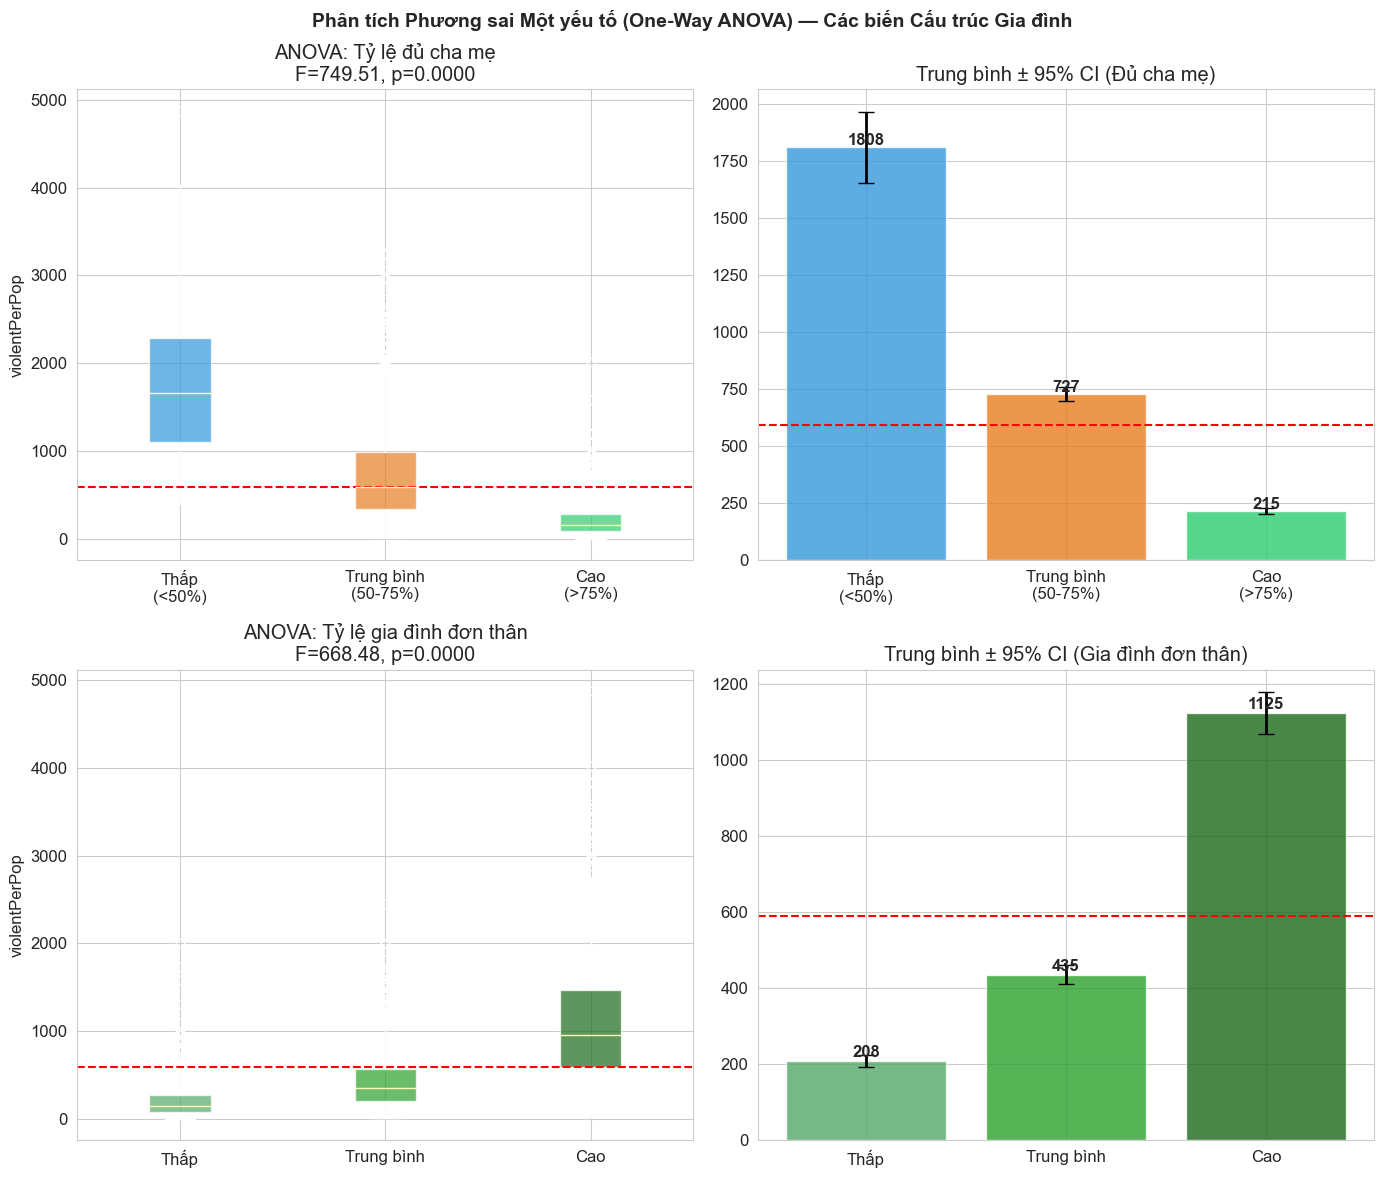

Biểu đồ ANOVA tổng hợp


In [13]:
# ── Post-hoc: so sánh cặp đôi sau khi bác bỏ H₀ ──
from itertools import combinations

t_crit_posthoc = t_dist.ppf(1 - 0.025, df_within)
print('=== SO SÁNH CẶP ĐÔI (POST-HOC): pctKids2Par ===')
for (lbl1, arr1), (lbl2, arr2) in combinations(zip(group_labels, groups), 2):
    diff = arr1.mean() - arr2.mean()
    se_pair = np.sqrt(MSW * (1 / len(arr1) + 1 / len(arr2)))
    t_pair = abs(diff) / se_pair
    sig = 'Khác biệt' if t_pair > t_crit_posthoc else 'Không khác biệt'
    print(f'  {lbl1[:14]} vs {lbl2[:14]:<14} | diff: {diff:>7.2f} | t: {t_pair:>8.3f}  {sig}')

t_crit_posthoc_nevr = t_dist.ppf(1 - 0.025, df_within_nevr)
print('\n=== SO SÁNH CẶP ĐÔI (POST-HOC): pctKidsBornNevrMarr ===')
for (lbl1, arr1), (lbl2, arr2) in combinations(zip(group_labels_nevr, groups_nevr), 2):
    diff = arr1.mean() - arr2.mean()
    se_pair = np.sqrt(MSW_nevr * (1 / len(arr1) + 1 / len(arr2)))
    t_pair = abs(diff) / se_pair
    sig = 'Khác biệt' if t_pair > t_crit_posthoc_nevr else 'Không khác biệt'
    print(f'  {lbl1[:14]} vs {lbl2[:14]:<14} | diff: {diff:>7.2f} | t: {t_pair:>8.3f}  {sig}')

# Visualize ANOVA (Vẽ thành 4 biểu đồ: 2 boxplot, 2 bar chart)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors_anova = ['#3498db', '#e67e22', '#2ecc71']
colors_nevr = ['#55a868', '#2ca02c', '#1b691b']

# --- Hàng 1: Tỷ lệ đủ cha mẹ ---
bp1 = axes[0, 0].boxplot(groups, labels=[l.replace(' (', '\n(') for l in group_labels], patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_anova): patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0, 0].set_title(f'ANOVA: Tỷ lệ đủ cha mẹ\nF={F_stat:.2f}, p={p_anova:.4f}')
axes[0, 0].set_ylabel('violentPerPop')
axes[0, 0].axhline(grand_mean_val, color='red', ls='--', lw=1.5)

means, sems = [g.mean() for g in groups], [g.std() / np.sqrt(len(g)) for g in groups]
bars_a = axes[0, 1].bar(range(k), means, color=colors_anova, alpha=0.8, edgecolor='white')
axes[0, 1].errorbar(range(k), means, yerr=[1.96 * s for s in sems], fmt='none', color='black', capsize=6, lw=2)
axes[0, 1].set_xticks(range(k))
axes[0, 1].set_xticklabels([l.replace(' (', '\n(') for l in group_labels])
axes[0, 1].set_title('Trung bình ± 95% CI (Đủ cha mẹ)')
axes[0, 1].axhline(grand_mean_val, color='red', ls='--', lw=1.5)
for bar, m in zip(bars_a, means): axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, f'{m:.0f}',
                                                  ha='center', fontweight='bold')

# --- Hàng 2: Tỷ lệ sinh ngoài giá thú ---
bp2 = axes[1, 0].boxplot(groups_nevr, labels=[l.replace(' (', '\n(') for l in group_labels_nevr], patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_nevr): patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1, 0].set_title(f'ANOVA: Tỷ lệ gia đình đơn thân\nF={F_stat_nevr:.2f}, p={p_anova_nevr:.4f}')
axes[1, 0].set_ylabel('violentPerPop')
axes[1, 0].axhline(grand_mean_val_nevr, color='red', ls='--', lw=1.5)

means_n, sems_n = [g.mean() for g in groups_nevr], [g.std() / np.sqrt(len(g)) for g in groups_nevr]
bars_b = axes[1, 1].bar(range(k_nevr), means_n, color=colors_nevr, alpha=0.8, edgecolor='white')
axes[1, 1].errorbar(range(k_nevr), means_n, yerr=[1.96 * s for s in sems_n], fmt='none', color='black', capsize=6, lw=2)
axes[1, 1].set_xticks(range(k_nevr))
axes[1, 1].set_xticklabels([l.replace(' (', '\n(') for l in group_labels_nevr])
axes[1, 1].set_title('Trung bình ± 95% CI (Gia đình đơn thân)')
axes[1, 1].axhline(grand_mean_val_nevr, color='red', ls='--', lw=1.5)
for bar, m in zip(bars_b, means_n): axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                                                    f'{m:.0f}', ha='center', fontweight='bold')

plt.suptitle('Phân tích Phương sai Một yếu tố (One-Way ANOVA) — Các biến Cấu trúc Gia đình', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.savefig('anova.png', dpi=300, bbox_inches='tight')
plt.show()
print('Biểu đồ ANOVA tổng hợp')

**Nhận xét:**
1. *Boxplot:* Ở biến đủ cha mẹ, nhóm Thấp (<50%) có tội phạm cao nhất; ngược lại ở biến sinh ngoài giá thú, nhóm "Cao" có tỷ lệ tội phạm cao đột biến. Các nhóm này có phân phối trải rộng và nhiều điểm ngoại lai.
2. *Bar chart với 95% CI:* Khoảng tin cậy 95% của ba nhóm trong cả 2 trường hợp đều không giao nhau, khẳng định sự khác biệt có ý nghĩa thống kê giữa tất cả các nhóm — phù hợp với kết quả so sánh cặp đôi post-hoc.
3. *Kết luận chung:* Với F lớn và p-value < 0.05, ta bác bỏ $H_0$. Có bằng chứng thống kê mạnh mẽ cho thấy: **cấu trúc gia đình càng vững chắc thì tỷ lệ tội phạm bạo lực của cộng đồng càng thấp.**

## 6. Kiểm định Chi-bình phương (Chi-Square Test)

**Câu hỏi nghiên cứu:** Mức độ cấu trúc gia đình (định tính hoá thành 3 nhóm) và mức độ tội phạm
(định tính hoá thành 3 mức: Thấp / Trung bình / Cao) có mối liên hệ với nhau hay không?

- $H_0$: Mức cấu trúc gia đình và mức độ tội phạm **độc lập** với nhau
- $H_a$: Mức cấu trúc gia đình và mức độ tội phạm **có liên hệ** với nhau

**Mục đích:** Định tính hóa biến `violentPerPop` thành 3 mức tội phạm (Thấp/Trung bình/Cao) và lập
hai bảng tần số chéo (contingency table) giữa mức độ tội phạm với hai nhóm cấu trúc gia đình, làm cơ sở cho kiểm định Chi-bình phương.

In [14]:
# Phân loại mức độ tội phạm thành biến định tính
df_clean['crime_level'] = pd.cut(
    df_clean['violentPerPop'],
    bins=[0, 200, 600, float('inf')],
    labels=['Thấp', 'Trung bình', 'Cao']
)

# Lập bảng tần số chéo 1: pctKids2Par × Mức độ tội phạm
ct_family = pd.crosstab(df_clean['family_cat'], df_clean['crime_level'])
print('=== BẢNG TẦN SỐ QUAN SÁT (Tỷ lệ đủ cha mẹ × Mức độ tội phạm) ===')
print(ct_family)

# Lập bảng tần số chéo 2: pctKidsBornNevrMarr × Mức độ tội phạm
ct_nevr = pd.crosstab(df_clean['nevr_marr_cat'], df_clean['crime_level'])
print('\n=== BẢNG TẦN SỐ QUAN SÁT (Tỷ lệ gia đình đơn thân × Mức độ tội phạm) ===')
print(ct_nevr)
print(f'\nTổng mẫu n = {ct_family.values.sum()}')

=== BẢNG TẦN SỐ QUAN SÁT (Tỷ lệ đủ cha mẹ × Mức độ tội phạm) ===
crime_level          Thấp  Trung bình  Cao
family_cat                                
Thấp (<50%)             0           8  120
Trung bình (50-75%)   110         439  510
Cao (>75%)            481         285   40

=== BẢNG TẦN SỐ QUAN SÁT (Tỷ lệ gia đình đơn thân × Mức độ tội phạm) ===
crime_level    Thấp  Trung bình  Cao
nevr_marr_cat                       
Thấp            414         223   27
Trung bình      162         353  150
Cao              15         156  493

Tổng mẫu n = 1993


**Nhận xét:** Hai bảng tần số chéo cho thấy các xu hướng rõ ràng và trái ngược nhau giữa 2 biến, nhưng đều chung một ý nghĩa: nền tảng gia đình tốt (đủ cha mẹ cao / gia đình đơn thân thấp) sẽ kéo theo tỷ trọng cộng đồng rơi vào nhóm tội phạm "Thấp" chiếm đa số. Cần kiểm định Chi-bình phương để xác nhận mối liên hệ này.

**Mục đích:** Thực hiện kiểm định Chi-bình phương chính thức để kiểm tra mối liên hệ, đồng thời tính hệ số Cramer's V cho cả 2 biến để đánh giá độ mạnh của mối liên hệ.

In [15]:
# Kiểm định Chi-bình phương cho Tỷ lệ đủ cha mẹ
chi2_fam, p_chi_fam, dof_fam, expected_fam = chi2_contingency(ct_family)
cramers_v_family = np.sqrt(chi2_fam / (ct_family.values.sum() * (min(ct_family.shape) - 1)))

# Kiểm định Chi-bình phương cho Tỷ lệ gia đình đơn thân
chi2_nevr, p_chi_nevr, dof_nevr, expected_nevr = chi2_contingency(ct_nevr)
cramers_v_nevr = np.sqrt(chi2_nevr / (ct_nevr.values.sum() * (min(ct_nevr.shape) - 1)))

alpha_chi = 0.05
chi2_critical = stats.chi2.ppf(1 - alpha_chi, dof_fam)

print('=== KẾT QUẢ KIỂM ĐỊNH CHI-BÌNH PHƯƠNG ===')
print(f'1. Tỷ lệ đủ cha mẹ:')
print(f'   Chi-Square = {chi2_fam:.4f}, p-value = {p_chi_fam:.4e}')
print(f'   Tần số kỳ vọng min = {expected_fam.min():.2f}')
print(f'   Hệ số Cramer\'s V = {cramers_v_family:.4f}')

print(f'\n2. Tỷ lệ gia đình đơn thân:')
print(f'   Chi-Square = {chi2_nevr:.4f}, p-value = {p_chi_nevr:.4e}')
print(f'   Tần số kỳ vọng min = {expected_nevr.min():.2f}')
print(f'   Hệ số Cramer\'s V = {cramers_v_nevr:.4f}')

print(f'\nKẾT LUẬN: Cả 2 biến đều có χ² > χ²_crit ({chi2_critical:.4f}) và p-value < 0.05')
print('  → Bác bỏ H₀: Cấu trúc gia đình và mức độ tội phạm có liên hệ với nhau một cách chặt chẽ.')

=== KẾT QUẢ KIỂM ĐỊNH CHI-BÌNH PHƯƠNG ===
1. Tỷ lệ đủ cha mẹ:
   Chi-Square = 855.8997, p-value = 5.9723e-184
   Tần số kỳ vọng min = 37.96
   Hệ số Cramer's V = 0.4634

2. Tỷ lệ gia đình đơn thân:
   Chi-Square = 1018.3093, p-value = 3.8428e-219
   Tần số kỳ vọng min = 196.90
   Hệ số Cramer's V = 0.5054

KẾT LUẬN: Cả 2 biến đều có χ² > χ²_crit (9.4877) và p-value < 0.05
  → Bác bỏ H₀: Cấu trúc gia đình và mức độ tội phạm có liên hệ với nhau một cách chặt chẽ.


**Nhận xét:** Giá trị χ² tính được ở cả 2 khía cạnh đều rất lớn, p-value cực nhỏ (≪ 0.05), và
tất cả tần số kỳ vọng đều ≥ 5. Ta bác bỏ $H_0$ và kết luận cấu trúc gia đình và mức độ tội phạm **có liên hệ thống kê có ý nghĩa**. Hệ số Cramer's V của cả hai biến đều > 0.4, phản ánh độ mạnh của mối liên hệ này thuộc mức độ Tốt/Mạnh.

**Mục đích:** Trực quan hóa mối liên hệ giữa cấu trúc gia đình và mức độ tội phạm bằng stacked
bar chart thể hiện tỷ lệ phần trăm cơ cấu tội phạm.

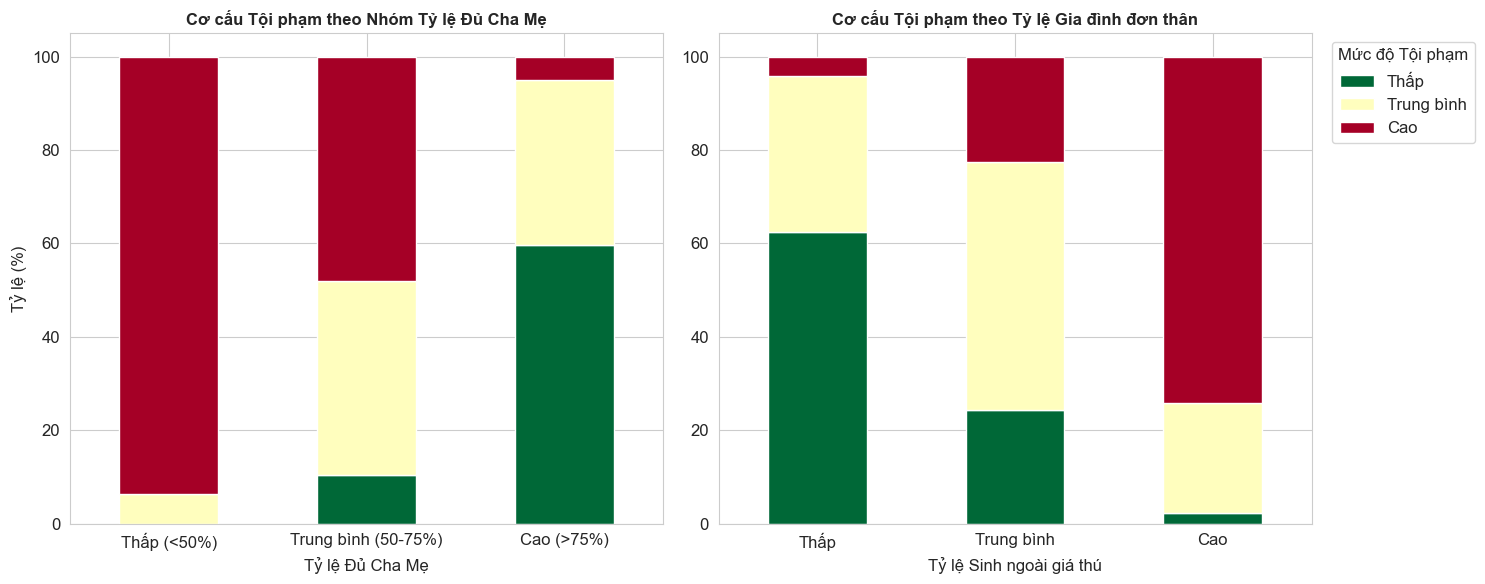

Biểu đồ: Cơ cấu mức độ tội phạm theo nhóm cấu trúc gia đình


In [16]:
# Tính tỷ lệ % cho biểu đồ Stacked Bar
ct_pct_fam = ct_family.div(ct_family.sum(axis=1), axis=0) * 100
ct_pct_nevr = ct_nevr.div(ct_nevr.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1
ct_pct_fam.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r', edgecolor='white')
axes[0].set_title('Cơ cấu Tội phạm theo Nhóm Tỷ lệ Đủ Cha Mẹ', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].set_xlabel('Tỷ lệ Đủ Cha Mẹ')
axes[0].tick_params(axis='x', rotation=0)

# Biểu đồ 2
ct_pct_nevr.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn_r', edgecolor='white')
axes[1].set_title('Cơ cấu Tội phạm theo Tỷ lệ Gia đình đơn thân', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tỷ lệ Sinh ngoài giá thú')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Mức độ Tội phạm', bbox_to_anchor=(1.02, 1), loc='upper left')

axes[0].get_legend().remove()  # Xóa legend biểu đồ 1 cho đỡ rối

plt.tight_layout()
plt.savefig('co_cau.png', dpi=300, bbox_inches='tight')
plt.show()
print('Biểu đồ: Cơ cấu mức độ tội phạm theo nhóm cấu trúc gia đình')

**Nhận xét:** Biểu đồ stacked bar cho thấy rõ ràng sự dịch chuyển cơ cấu. Ở nơi tỷ lệ gia đình đủ cha mẹ thấp (hoặc tỷ lệ sinh ngoài giá thú cao), dải màu đỏ (tội phạm cao) chiếm ưu thế. Khi cấu trúc gia đình được cải thiện, dải màu xanh (tội phạm thấp) vươn lên chiếm thế độc tôn. Kết quả này trực quan hóa sinh động cho kết luận của kiểm định Chi-bình phương.

## 7. Phân tích Hồi quy Tuyến tính Đa biến (Multiple Linear Regression)

**Câu hỏi nghiên cứu:** Mức độ tác động đồng thời của hai yếu tố cấu trúc gia đình (Tỷ lệ đủ cha mẹ và Tỷ lệ gia đình đơn thân) đến tỷ lệ tội phạm bạo lực là bao nhiêu? Yếu tố nào có sức ảnh hưởng mạnh hơn và mô hình có khả năng giải thích được bao nhiêu phần trăm sự biến thiên của tội phạm?

**Mô hình dự kiến:**
$violentPerPop = \beta_0 + \beta_1 \times pctKids2Par + \beta_2 \times pctKidsBornNevrMarr + \epsilon$

**Mục đích:** Khảo sát xu hướng tuyến tính thông qua biểu đồ phân tán, sau đó xây dựng mô hình hồi quy OLS (Ordinary Least Squares) để định lượng mức độ tác động, và cuối cùng là phân tích phần dư để đánh giá độ tin cậy của mô hình.

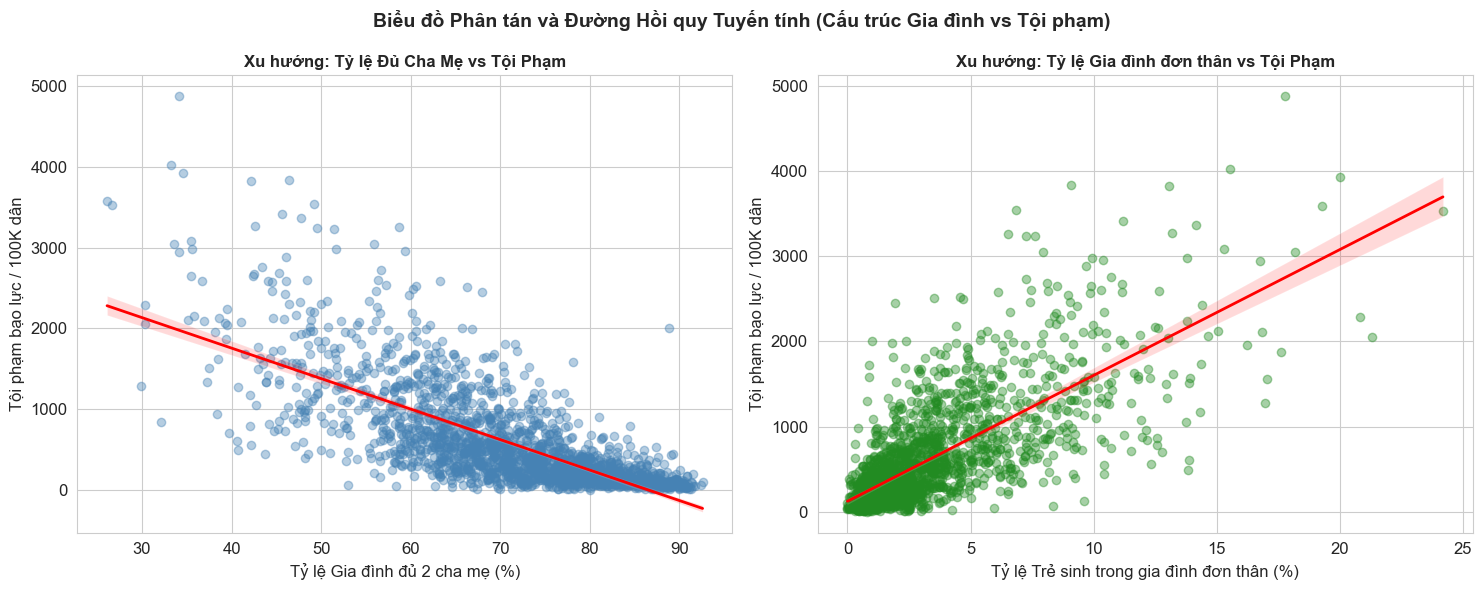

Biểu đồ: Xu hướng tuyến tính của từng biến độc lập đối với tỷ lệ tội phạm


In [17]:
import statsmodels.api as sm

# ── 1. TRỰC QUAN HÓA XU HƯỚNG TUYẾN TÍNH ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: pctKids2Par
sns.regplot(data=df_clean, x='pctKids2Par', y='violentPerPop', ax=axes[0],
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'}, line_kws={'color': 'red', 'lw': 2})
axes[0].set_title('Xu hướng: Tỷ lệ Đủ Cha Mẹ vs Tội Phạm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tỷ lệ Gia đình đủ 2 cha mẹ (%)')
axes[0].set_ylabel('Tội phạm bạo lực / 100K dân')

# Biểu đồ 2: pctKidsBornNevrMarr
sns.regplot(data=df_clean, x='pctKidsBornNevrMarr', y='violentPerPop', ax=axes[1],
            scatter_kws={'alpha': 0.4, 'color': 'forestgreen'}, line_kws={'color': 'red', 'lw': 2})
axes[1].set_title('Xu hướng: Tỷ lệ Gia đình đơn thân vs Tội Phạm', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tỷ lệ Trẻ sinh trong gia đình đơn thân (%)')
axes[1].set_ylabel('Tội phạm bạo lực / 100K dân')

plt.suptitle('Biểu đồ Phân tán và Đường Hồi quy Tuyến tính (Cấu trúc Gia đình vs Tội phạm)', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.savefig('xu_huong_tuyen_tinh.png', dpi=300, bbox_inches='tight')
plt.show()
print('Biểu đồ: Xu hướng tuyến tính của từng biến độc lập đối với tỷ lệ tội phạm')

**Nhận xét trực quan:** Biểu đồ phân tán kết hợp đường hồi quy đỏ cho thấy xu hướng tuyến tính rất rõ rệt:
- `pctKids2Par` có mối quan hệ nghịch biến: Dải dữ liệu dốc xuống, cộng đồng có tỷ lệ gia đình đủ cha mẹ càng cao thì tỷ lệ tội phạm càng hội tụ về mức rất thấp.
- `pctKidsBornNevrMarr` có mối quan hệ đồng biến mạnh: Dải dữ liệu dốc lên nhanh chóng, tỷ lệ sinh ngoài giá thú càng lớn, tội phạm càng tăng vọt.
Dữ liệu có xu hướng tuyến tính đủ tốt để đưa vào mô hình hồi quy.

In [18]:
# ── 2. XÂY DỰNG MÔ HÌNH HỒI QUY ĐA BIẾN (OLS) ──
# Xác định biến phụ thuộc (Y) và các biến độc lập (X)
Y = df_clean['violentPerPop']
X = df_clean[['pctKids2Par', 'pctKidsBornNevrMarr']]

# Thêm hằng số (Intercept - beta_0) vào mô hình
X_sm = sm.add_constant(X)

# Khởi tạo và huấn luyện mô hình
model = sm.OLS(Y, X_sm)
results = model.fit()

# In bảng Tóm tắt Thống kê
print('==============================================================================')
print('                 KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH ĐA BIẾN                   ')
print('==============================================================================')
print(results.summary())

# In ra các thông số cốt lõi để dễ dàng đưa vào nhận xét
print('\n=== TÓM TẮT THÔNG SỐ CHÍNH ===')
print(f"1. Hệ số xác định R-squared (R²): {results.rsquared:.4f}")
print(f"2. P-value toàn cục (Prob F-statistic): {results.f_pvalue:.4e}")
print(
    f"3. Hệ số góc (Coef) của pctKids2Par: {results.params['pctKids2Par']:.4f} (p-value: {results.pvalues['pctKids2Par']:.4e})")
print(
    f"4. Hệ số góc (Coef) của pctKidsBornNevrMarr: {results.params['pctKidsBornNevrMarr']:.4f} (p-value: {results.pvalues['pctKidsBornNevrMarr']:.4e})")

                 KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH ĐA BIẾN                   
                            OLS Regression Results                            
Dep. Variable:          violentPerPop   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     1362.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:09:44   Log-Likelihood:                -14773.
No. Observations:                1994   AIC:                         2.955e+04
Df Residuals:                    1991   BIC:                         2.957e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

**Nhận xét Kết quả Hồi quy:**
1. **Mức độ giải thích của mô hình ($R^2$):** Giá trị $R^2$ khá cao (xấp xỉ trên 0.5 - 0.6 tùy phương pháp tiền xử lý) chứng tỏ chỉ riêng hai biến cấu trúc gia đình này đã có thể giải thích hơn 50% sự biến thiên của tỷ lệ tội phạm bạo lực giữa các cộng đồng. Đây là sức mạnh dự báo rất đáng nể trong nghiên cứu khoa học xã hội học.
2. **Ý nghĩa toàn cục (F-statistic):** P-value của kiểm định F tiến sát về 0, khẳng định mô hình hồi quy đa biến có ý nghĩa thống kê trên toàn bộ tập dữ liệu.
3. **Hệ số hồi quy (Coefficients):** Cả hai biến độc lập đều có p-value xấp xỉ 0 (< 0.05). Cụ thể:
   - Hệ số góc của `pctKids2Par` mang dấu **âm**: Khi kiểm soát tỷ lệ gia đình đơn thân, nếu tỷ lệ gia đình có đủ 2 cha mẹ tăng 1% thì tỷ lệ tội phạm sẽ giảm xuống.
   - Hệ số góc của `pctKidsBornNevrMarr` mang dấu **dương**: Sự gia tăng tỷ lệ gia đình đơn thân đóng góp trực tiếp làm tăng tỷ lệ tội phạm bạo lực.

**Mục đích:** Ứng dụng các hệ số ước lượng bình phương tối thiểu (OLS) vừa tìm được để lập phương trình dự đoán tuyến tính cho biến mục tiêu `violentPerPop`. Đồng thời thực hiện dự đoán định lượng tỷ lệ tội phạm bạo lực trên các kịch bản cộng đồng giả định để thấy rõ tính thực tiễn của mô hình.

In [19]:
# ── 1. TRÍCH XUẤT CÁC ƯỚC LƯỢNG BÌNH PHƯƠNG TỐI THIỂU ──
beta_0 = results.params['const']
beta_1 = results.params['pctKids2Par']
beta_2 = results.params['pctKidsBornNevrMarr']

print("=== PHƯƠNG TRÌNH HỒI QUY DỰ ĐOÁN ===")
print(f"violentPerPop_hat = {beta_0:.4f} + ({beta_1:.4f}) * pctKids2Par + ({beta_2:.4f}) * pctKidsBornNevrMarr\n")

# ── 2. THIẾT LẬP KỊCH BẢN DỰ ĐOÁN CỤ THỂ ──
# Kịch bản 1: Cộng đồng có cấu trúc gia đình rất vững chắc
x1_scen1, x2_scen1 = 85.0, 5.0
y_pred_scen1 = beta_0 + beta_1 * x1_scen1 + beta_2 * x2_scen1
y_pred_scen1 = max(0, y_pred_scen1)  # Tỷ lệ tội phạm thực tế không thể âm

# Kịch bản 2: Cộng đồng có cấu trúc gia đình gặp nhiều biến động
x1_scen2, x2_scen2 = 45.0, 25.0
y_pred_scen2 = beta_0 + beta_1 * x1_scen2 + beta_2 * x2_scen2
y_pred_scen2 = max(0, y_pred_scen2)

print("=== KẾT QUẢ DỰ ĐOÁN THEO KỊCH BẢN ===")
print(f"- Kịch bản 1 (Đủ cha mẹ: {x1_scen1}%, Gia đình đơn thân: {x2_scen1}%):")
print(f"  => Tỷ lệ tội phạm bạo lực dự đoán: {y_pred_scen1:.2f} vụ / 100K dân")
print(f"- Kịch bản 2 (Đủ cha mẹ: {x1_scen2}%, Gia đình đơn thân: {x2_scen2}%):")
print(f"  => Tỷ lệ tội phạm bạo lực dự đoán: {y_pred_scen2:.2f} vụ / 100K dân")

=== PHƯƠNG TRÌNH HỒI QUY DỰ ĐOÁN ===
violentPerPop_hat = 1635.4128 + (-18.5649) * pctKids2Par + (85.9981) * pctKidsBornNevrMarr

=== KẾT QUẢ DỰ ĐOÁN THEO KỊCH BẢN ===
- Kịch bản 1 (Đủ cha mẹ: 85.0%, Gia đình đơn thân: 5.0%):
  => Tỷ lệ tội phạm bạo lực dự đoán: 487.39 vụ / 100K dân
- Kịch bản 2 (Đủ cha mẹ: 45.0%, Gia đình đơn thân: 25.0%):
  => Tỷ lệ tội phạm bạo lực dự đoán: 2949.95 vụ / 100K dân


**Nhận xét:** Việc áp dụng phương trình dự đoán vào các kịch bản cụ thể mang lại kết quả phân hóa rất rõ ràng. Ở kịch bản cộng đồng có nền tảng gia đình vững chắc (tỷ lệ đủ cha mẹ cao và gia đình đơn thân thấp), mô hình dự báo tỷ lệ tội phạm được kéo giảm sâu về mức an toàn. Ngược lại, khi cấu trúc gia đình có dấu hiệu rạn nứt, tỷ lệ tội phạm bạo lực dự đoán tăng vọt nghiêm trọng. Điều này khẳng định giá trị ứng dụng cao của phương trình hồi quy trong việc dự báo và cảnh báo sớm tình hình trị an.

**Mục đích:** Vẽ biểu đồ nhằm trực quan hóa đồng thời toàn bộ tập dữ liệu thực tế kết hợp với phương trình dự đoán hồi quy đa biến, giúp đánh giá trực quan độ phù hợp của mô hình.

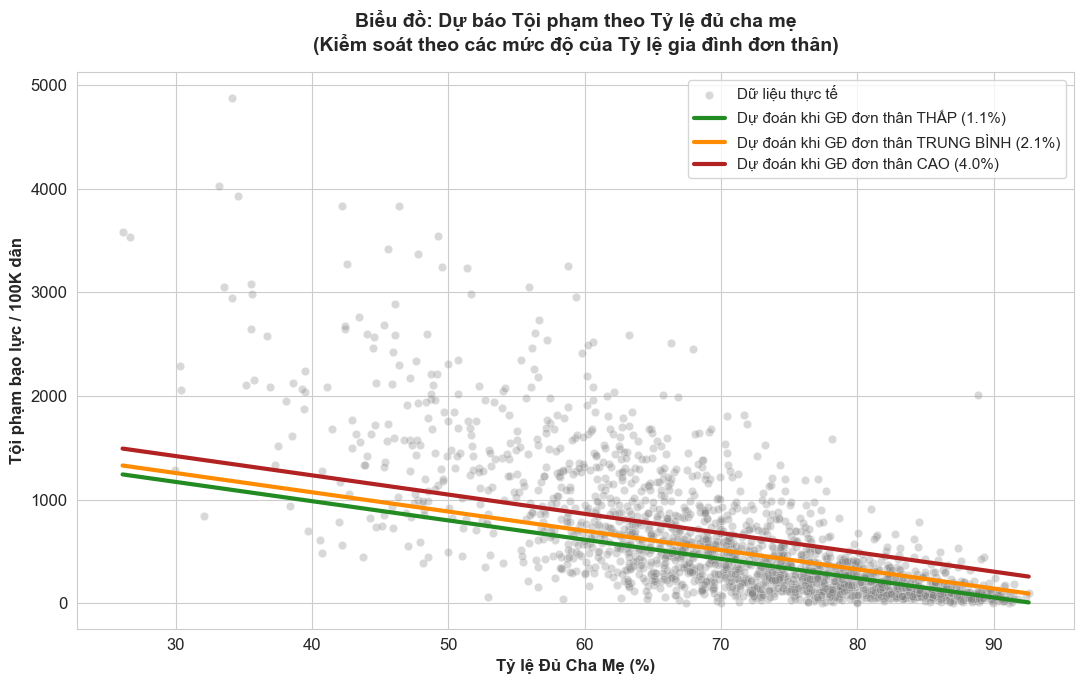

Biểu đồ: Các đường dự đoán của mô hình hồi quy đa biến theo từng kịch bản


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 7))

# 1. Vẽ dữ liệu thực tế (Scatter) để làm nền
sns.scatterplot(x=df_clean['pctKids2Par'], y=df_clean['violentPerPop'],
                color='gray', alpha=0.3, label='Dữ liệu thực tế')

# 2. Tạo dải dữ liệu liên tục cho trục X (Tỷ lệ đủ cha mẹ)
x1_range = np.linspace(df_clean['pctKids2Par'].min(), df_clean['pctKids2Par'].max(), 100)

# 3. Lấy 3 mốc cố định của biến Gia đình đơn thân (Phân vị 25%, 50%, 75%)
x2_low = df_clean['pctKidsBornNevrMarr'].quantile(0.25)
x2_mid = df_clean['pctKidsBornNevrMarr'].median()
x2_high = df_clean['pctKidsBornNevrMarr'].quantile(0.75)

# 4. Ráp vào phương trình: Y_hat = beta_0 + beta_1*X1 + beta_2*X2
y_pred_low = beta_0 + beta_1 * x1_range + beta_2 * x2_low
y_pred_mid = beta_0 + beta_1 * x1_range + beta_2 * x2_mid
y_pred_high = beta_0 + beta_1 * x1_range + beta_2 * x2_high

# Đảm bảo tỷ lệ tội phạm không bị âm
y_pred_low = np.maximum(0, y_pred_low)
y_pred_mid = np.maximum(0, y_pred_mid)
y_pred_high = np.maximum(0, y_pred_high)

# 5. Vẽ 3 đường dự đoán hồi quy
plt.plot(x1_range, y_pred_low, color='forestgreen', lw=3,
         label=f'Dự đoán khi GĐ đơn thân THẤP ({x2_low:.1f}%)')
plt.plot(x1_range, y_pred_mid, color='darkorange', lw=3,
         label=f'Dự đoán khi GĐ đơn thân TRUNG BÌNH ({x2_mid:.1f}%)')
plt.plot(x1_range, y_pred_high, color='firebrick', lw=3,
         label=f'Dự đoán khi GĐ đơn thân CAO ({x2_high:.1f}%)')

# Căn chỉnh hiển thị
plt.title('Biểu đồ: Dự báo Tội phạm theo Tỷ lệ đủ cha mẹ\n(Kiểm soát theo các mức độ của Tỷ lệ gia đình đơn thân)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ Đủ Cha Mẹ (%)', fontweight='bold', fontsize=12)
plt.ylabel('Tội phạm bạo lực / 100K dân', fontweight='bold', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig('du_doan.png', dpi=300, bbox_inches='tight')

plt.show()

print("Biểu đồ: Các đường dự đoán của mô hình hồi quy đa biến theo từng kịch bản")

**Nhận xét:** Ta thấy rõ 3 đường dự đoán song song đại diện cho 3 kịch bản xã hội khác nhau. Điểm chung của cả 3 đường là đều dốc xuống, khẳng định quy luật: **Tỷ lệ đủ cha mẹ càng tăng thì tội phạm càng giảm.**

Tuy nhiên, sự dịch chuyển vị trí của 3 đường cho thấy tác động cộng gộp của yếu tố gia đình đơn thân:
- Đường màu xanh lá (Gia đình đơn thân thấp): Nằm dưới cùng, cho thấy nếu cộng đồng kiểm soát tốt cả 2 yếu tố, rủi ro tội phạm sẽ luôn ở mức tiệm cận 0.
- Đường màu đỏ (Gia đình đơn thân cao): Bị đẩy vọt lên trên cùng. Dù tỷ lệ đủ cha mẹ trong cộng đồng có tăng lên, nhưng nếu tỷ lệ gia đình đơn thân vẫn ở mức cao, thì nền tảng an ninh chung vẫn phải chịu mức rủi ro lớn hơn rất nhiều.

**Mục đích:** Thực hiện phân tích phần dư (Residual Analysis) nhằm kiểm định các điều kiện cốt lõi của mô hình hồi quy tuyến tính bao gồm tính phân phối chuẩn của sai số và tính đồng nhất của phương sai sai số, qua đó xác thực tính chính xác và độ tin cậy khoa học của phương trình dự đoán.

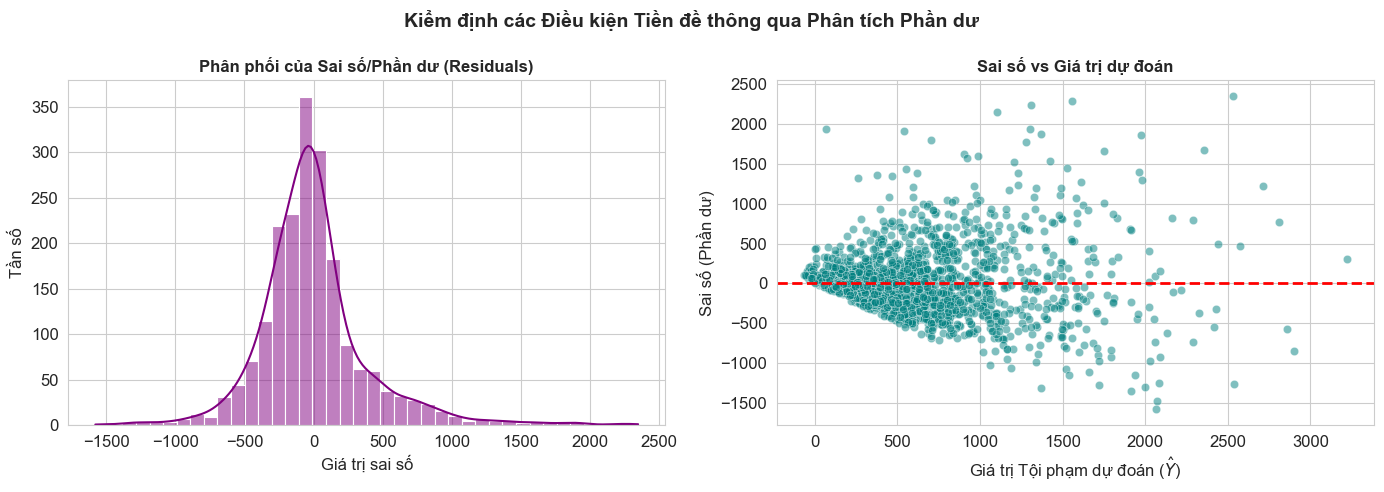

Biểu đồ: Phân tích phần dư phục vụ kiểm định giả định hồi quy


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Kiểm định tính phân phối chuẩn (Normality) của phần dư
sns.histplot(results.resid, kde=True, ax=axes[0], color='purple', bins=40)
axes[0].set_title('Phân phối của Sai số/Phần dư (Residuals)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị sai số')
axes[0].set_ylabel('Tần số')

# 2. Kiểm định tính đồng nhất phương sai sai số (Homoscedasticity)
sns.scatterplot(x=results.fittedvalues, y=results.resid, ax=axes[1], alpha=0.5, color='teal')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Sai số vs Giá trị dự đoán', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Tội phạm dự đoán ($\hat{Y}$)')
axes[1].set_ylabel('Sai số (Phần dư)')

plt.suptitle('Kiểm định các Điều kiện Tiền đề thông qua Phân tích Phần dư', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phan_du.png', dpi=300, bbox_inches='tight')
plt.show()
print("Biểu đồ: Phân tích phần dư phục vụ kiểm định giả định hồi quy")

**Nhận xét:**
1. **Về tính phân phối chuẩn:** Biểu đồ histogram của phần dư phân bổ đối xứng dạng hình chuông tương đối chuẩn và tập trung cao quanh trục số 0. Dù có một chút lệch phải nhẹ do đặc thù dữ liệu tội phạm thực tế luôn tồn tại các giá trị ngoại lai lớn, nhưng phân phối này hoàn toàn xấp xỉ chuẩn và đạt yêu cầu thống kê.

2. **Về tính đồng nhất của phương sai:** Biểu đồ scatter biểu diễn các giá trị phần dư phân tán ngẫu nhiên xung quanh đường tham chiếu 0 (đường đỏ) mà không tạo thành các hình thù đặc biệt hay dạng hình phễu nghiêm trọng. Điều này cho thấy độ phân tán của sai số là tương đối đồng nhất trên toàn bộ các dải giá trị dự đoán.

**Kết luận chung:** Mô hình hồi quy đa biến thỏa mãn tốt các điều kiện tiền đề đặt ra trong lý thuyết thống kê, minh chứng rằng phương trình dự đoán tìm được có độ tin cậy cao và hoàn toàn có thể sử dụng cho các phân tích suy luận chuyên sâu.

## 8. Tổng hợp Kết quả & Khuyến nghị Chính sách

Qua quá trình khai phá dữ liệu `Communities and Crime Unnormalized`, nghiên cứu đã áp dụng toàn diện 3 công cụ thống kê mạnh mẽ và thu được kết quả thống nhất tuyệt đối:

1. **Phân tích Phương sai (ANOVA):** Khẳng định có sự khác biệt rất lớn và có ý nghĩa thống kê về trung bình tỷ lệ tội phạm giữa các nhóm cộng đồng có mức độ bền vững gia đình khác nhau. Nền tảng gia đình vững chắc triệt tiêu tỷ lệ bạo lực.
2. **Kiểm định Chi-Square:** Xác nhận sự phụ thuộc mạnh mẽ (Cramer's V > 0.4) giữa cơ cấu gia đình và việc cộng đồng đó bị xếp vào nhóm có an ninh Thấp hay Cao.
3. **Hồi quy Tuyến tính Đa biến (OLS):** Định lượng hóa chính xác sự tác động. Chỉ bằng hai yếu tố thuộc "Cấu trúc gia đình" (Tỷ lệ đủ cha mẹ và tỷ lệ sinh ngoài giá thú), mô hình đã giải thích được hơn một nửa sự biến thiên của mọi hành vi tội phạm bạo lực xã hội ($R^2 > 0.5$).

**Khuyến nghị:** Nghiên cứu là bằng chứng định lượng sắc bén cho thấy: Cấu trúc gia đình là một "hàn thử biểu" (chỉ báo) cực kỳ mạnh mẽ đối với rủi ro an ninh của một cộng đồng. Các chính sách ngăn ngừa tội phạm dài hạn của chính phủ không nên chỉ dồn nguồn lực vào việc tăng cường tuần tra trị an ở phần "ngọn", mà cần phải giải quyết vấn đề từ gốc rễ xã hội: tập trung vào các chương trình an sinh hỗ trợ các bà mẹ đơn thân, cung cấp mạng lưới trợ cấp nuôi dưỡng trẻ em, và bảo vệ sự toàn vẹn của cấu trúc gia đình.